<h3>LLM Architecture</h3>

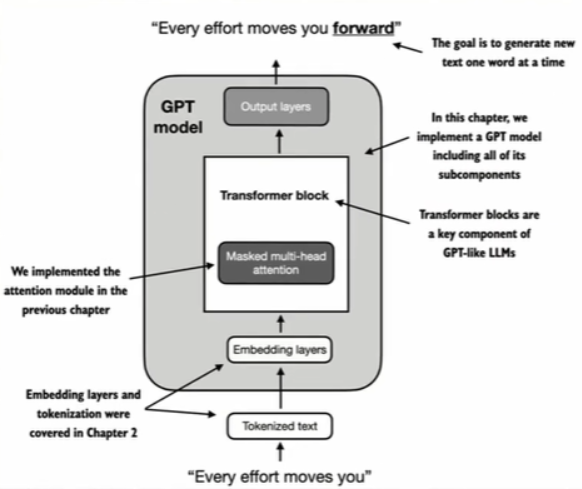

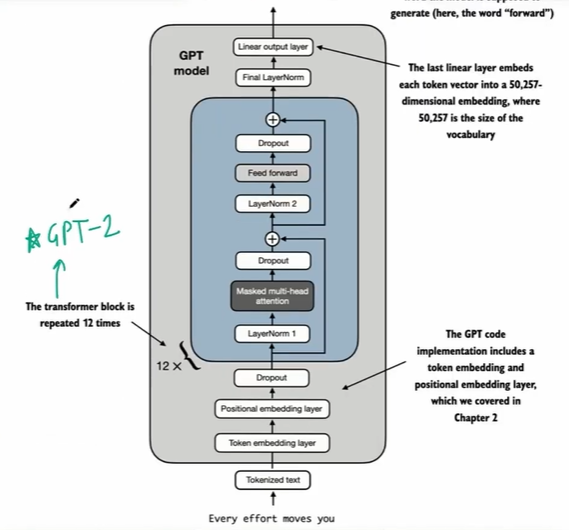
<h3>Transformer architecture</h3>

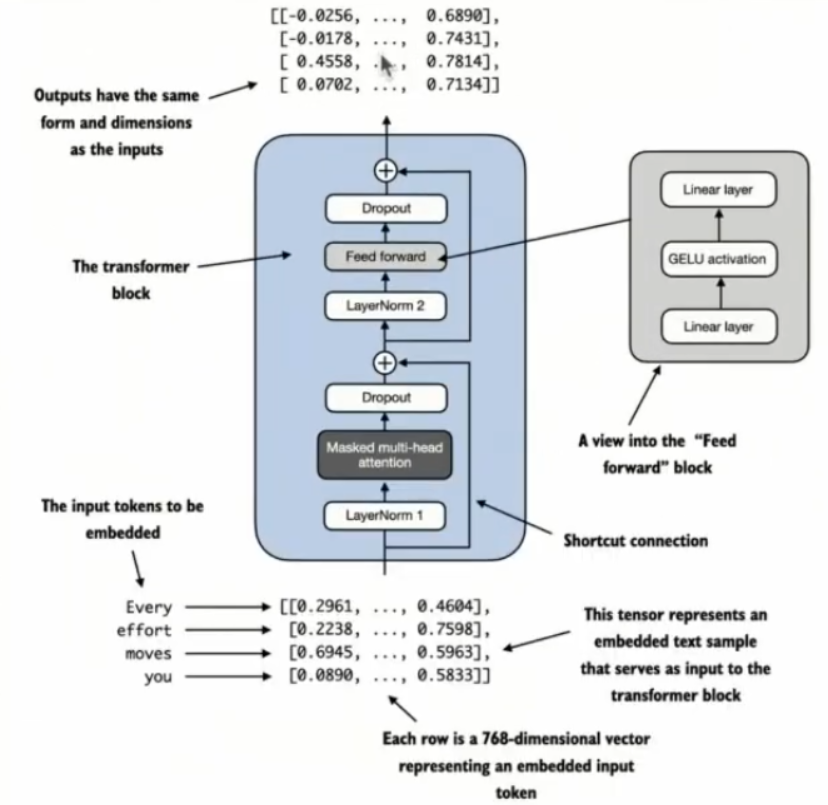

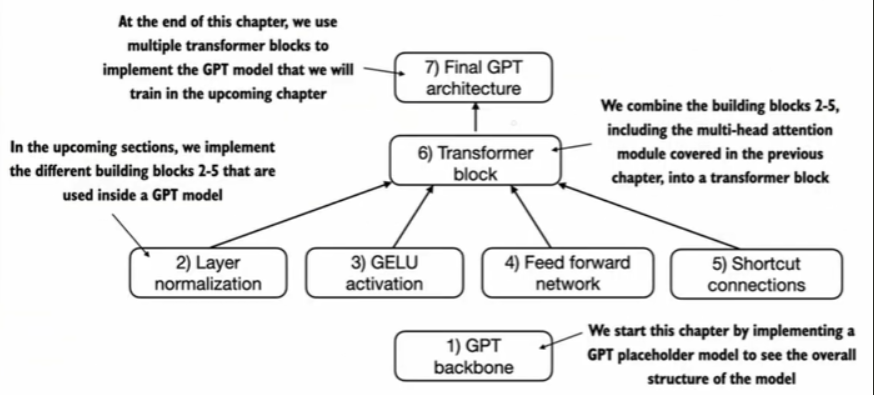

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

<h1>GPT ARCHITECTURE PART 1: DUMMY GPT MODEL CLASS (Bird's eye view)</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Step 1: Use a placeholder for TransformerBlock<br>
    Step 2: Use a placeholder for LayerNorm
</div>

In [3]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The DummyGPTModel class in this code defines a simplified version of a GPT-like model using PyTorch's neural network module (nn.Module).</li>
        <li>The model architecture in the DummyGPTModel class consists of token and positional embeddings, dropout, a series of transformer blocks (DummyTransformerBlock), a final layer normalization (DummyLayerNorm), and a linear output layer (out_head).</li>
        <li>The configuration is passed in via a Python dictionary, for instance, the GPT_CONFIG_124M dictionary we created earlier.</li>
        <li>The forward method describes the data flow through the model: it computes token and positional embeddings for the input indices, applies dropout, processes the data through the transformer blocks, applies normalization, and finally produces logits with the linear output layer.</li>
        <li>The code above is already functional, as we will see later in this section after we prepare the input data.</li>
        <li>However, for now, note in the code above that we have used placeholders (DummyLayerNorm and DummyTransformerBlock) for the transformer block and layer normalization, which we will develop in later sections</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, we will prepare the input data and initialize a new GPT model to illustrate its usage.
</div>

<h4>STEP 1: TOKENIZATION</h4>

In [4]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


<h4>STEP 2: CREATE AN INSTANCE OF DUMMYGPTMODEL</h4>

In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The output tensor has two rows corresponding to the two text samples. Each text sample consists of 4 tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.</li>
        <li>The embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. At the end of this chapter, when we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words.</li>
        <li>Each cells of this 50,257-dimensional vector stores probabilities for each word from vocabulary and next word that is predicted will have highest probability in this 50,257-dimensional vector.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Now that we have taken a top-down look at the GPT architecture and its in- and outputs, we will code the individual placeholders in the upcoming sections, starting with the real layer normalization class that will replace the DummyLayerNorm in the previous code.
</div>

<h1>GPT ARCHITECTURE PART 2: LAYER NORMALIZATION</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Training deep neural networks with many layers can be challenging due to vanishing/exploding gradients.</li>
        <li>This leads to unstable training dynamics.</li>
        <li>Layer normalization improves the stability and efficiency of neural network trainingul.</li>
        <li>If layer output is too large or small, gradient magnitudes can become too large or small. This affects training. Layer normalization keeps gradient stable.</li>
        <li>As the training proceeds, inputs to each layer can change (Internal covariant shift). This delays convergence. Layer normalization prevents this.</li>
        <li><b>Main Idea</b> : Adjust outputs of neural network to have mean equal to zero and variance equal to one. This speeds up the convergence.</li>
        <li>In GPT-2 and modern transformer architectures, layer normalization is typically applied before and after the multi-head attention module and before the final output layer.</li>
    </ul>
</div>

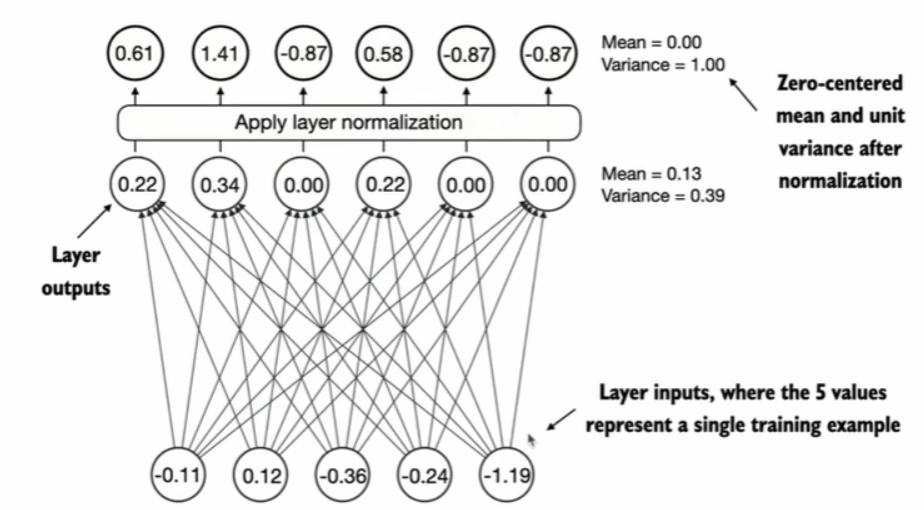

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's take an example. We have 2 batches of inputs and each batch has 5 inputs. We'll pass this two batches to layer of 6 neurons. Which produces 6 outputs for each batch.
</div>

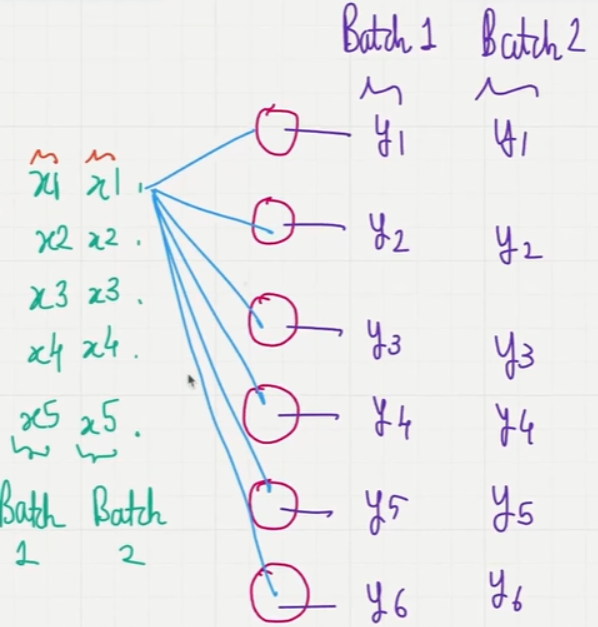

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    As displayed in above image, We'll get two batches of output.
</div>

In [6]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5) #2 batches and each batch has 5 inputs
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    In above code, we have an input. A tensor of sixe 2*5 which means we've 2 batches of inputs and each batch has 5 inputs. Inn output we'll get tensor of size 2*6 which means we'll get 2 batches and each batch has 6 outputs 
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The neural network layer we have coded consists of a Linear layer followed by a non-linear activation function, ReLU (short for Rectified Linear Unit), which is a standard activation function in neural networks.</li>
        <li>If you are unfamiliar with ReLU, it simply thresholds negative inputs to 0, ensuring that a layer outputs only positive values, which explains why the resulting layer output does not contain any negative values.</li>
        <li>(Note that we will use another, more sophisticated activation function in GPT, which we will introduce in the next section).</li>
    </ul> 
<div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Before we apply layer normalization to these outputs, let's examine the mean and variance:
</div>

In [7]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The first row in the mean tensor above contains the mean value for the first input row, and the second output row contains the mean for the second input row.</li>
        <li>Using keepdim=True in operations like mean or variance calculation ensures that the output tensor retains the same number of dimensions as the input tensor, even though the operation reduces the tensor along the dimension specified via dim.</li>
        <li>For instance, without keepdim=True, the returned mean tensor would be a 2-dimensional vector [0.1324, 0.2170] instead of a 2×1-dimensional matrix [[0.1324], [0.2170]].</li>
        <li>For a 2D tensor (like a matrix), using dim=-1 for operations such as mean or variance calculation is the same as using dim=1.</li>
        <li>This is because -1 refers to the tensor's last dimension, which corresponds to the columns in a 2D tensor.</li>
        <li>Later, when adding layer normalization to the GPT model, which produces 3D tensors with shape [batch_size, num_tokens, embedding_size], we can still use dim=-1 for normalization across the last dimension, avoiding a change from dim=1 to dim=2.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, let us apply layer normalization to the layer outputs we obtained earlier. The operation consists of subtracting the mean and dividing by the square root of the variance (also known as standard deviation):
</div>

In [8]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Note that the value 9.9341e-09 in the output tensor is the scientific notation for 9.9341 × 10-9, which is 0.0000000099341 in decimal form. This value is very close to 0, but it is not exactly 0 due to small numerical errors that can accumulate because of the finite precision with which computers represent numbers.
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    To improve readability, we can also turn off the scientific notation when printing tensor values by setting sci_mode to False:
</div>

In [9]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's now encapsulate this process in a PyTorch module that we can use in the GPT model later:
</div>

In [10]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>This specific implementation of layer Normalization operates on the last dimension of the input tensor x, which represents the embedding dimension (emb_dim).</li>
        <li>The variable eps is a small constant (epsilon) added to the variance to prevent division by zero during normalization.</li>
        <li>The scale and shift are two trainable parameters (of the same dimension as the input) that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.</li>
        <li>This allows the model to learn appropriate scaling and shifting that best suit the data it is processing.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    A small note on biased variance:<br>
    <ul>
        <li>In our variance calculation method, we have opted for an implementation detail by setting unbiased=False. For those curious about what this means, in the variance calculation, we divide by the number of inputs n in the variance formula.</li>
        <li>This approach does not apply Bessel's correction, which typically uses n-1 instead of n in the denominator to adjust for bias in sample variance estimation.</li>
        <li>This decision results in a so-called biased estimate of the variance.</li>
        <li>For large-scale language models (LLMs), where the embedding dimension n is significantly large, the difference between using n and n-1 is practically negligible.</li>
        <li>We chose this approach to ensure compatibility with the GPT-2 model's normalization layers and because it reflects TensorFlow's default behavior, which was used to implement the original GPT2 model.</li>
    </ul>
</div>

In [11]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    As we can see based on the results, the layer normalization code works as expected and normalizes the values of each of the two inputs such that they have a mean of 0 and a variance of 1
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Difference between Layer normalization vs Batch normalization :<br>
    <ul>
        <li>Batch normalization is not that feasible as it depends on batch size. And batch size depends on available hardware. If numbe rof hardware is less than you have to reduce batch size.</li>
        <li>Layer normalizatuon leads to more flexibility and stability for distributed training (environment which lack resources).</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of layer normalization:</b><br>
    <ul>
        <li>In trnsormer block Layer Normalization is applied (2 times in one block) to the inputs so that mean of each embedding vectors (of token) should be 0 and variance should be 1.</li>
        <li>Normalization formula : <b>(x - mean) / torch.sqrt(var + self.eps)</b></li>
        <li>self.scale * norm_x + self.shift, Here scale and shift is also applied to normalized embedding vector which are trainable parameters.</li> 
    </ul>
</div>

<h1>GPT ARCHITECTURE PART 3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We will implement a small neural network sub-module that is a part of the LLM transformer block.</li>
        <li>In this section we'll learn about Feed forward block which also contains GELU activation.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Two activation functions commonly implemented
            <ul>
                <li>GELU</li>
                <li>SwiGLU</li>
            </ul>
        </li>
    </ul>
</div>

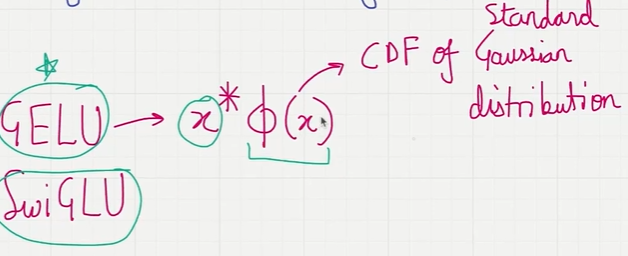

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Here is the GELU activation function approximation used for training GPT2:<br>
    GELU(x) ≈ 0.5x(1 + tanh(sqrt(2/pi)*(x + 0.044715*x^3)))
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Advantages of GELU : 
    <ul>
        <li>Graph of GELU is smoother than RELU. So GELU activation is differentiable across all x.</li>
        <li>RELU is for -ve x values but GELU is not 0 for -ve x, which solves dead neurons problem.</li>
        <li>GELU performs much better than RELU in context of LLMs.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let's implement GELU activation approximation used by GPT-2 :
</div>

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    To get an idea of what this GELU function looks like and how it compares to the ReLU function, let's plot these functions side by side:
</div>

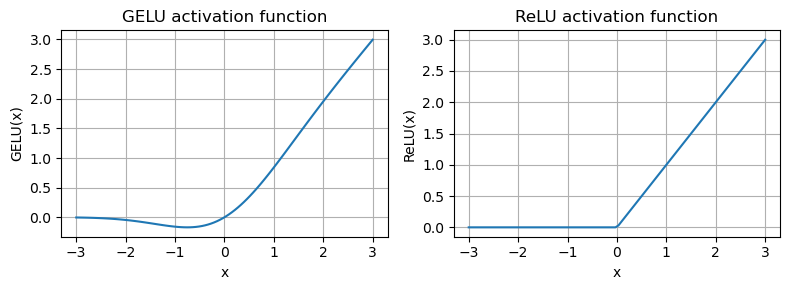

In [13]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see in the resulting plot, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero.</li>
        <li>GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.</li>
        <li>The smoothness of GELU, as shown in the above figure, can lead to better optimization properties during training, as it allows for more nuanced adjustments to the model's parameters.</li>
        <li>In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.</li>
        <li>Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output for negative values.</li>
        <li>This characteristic means that during the training process, neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Here's the illustration of Feed Forward neural network:
</div>

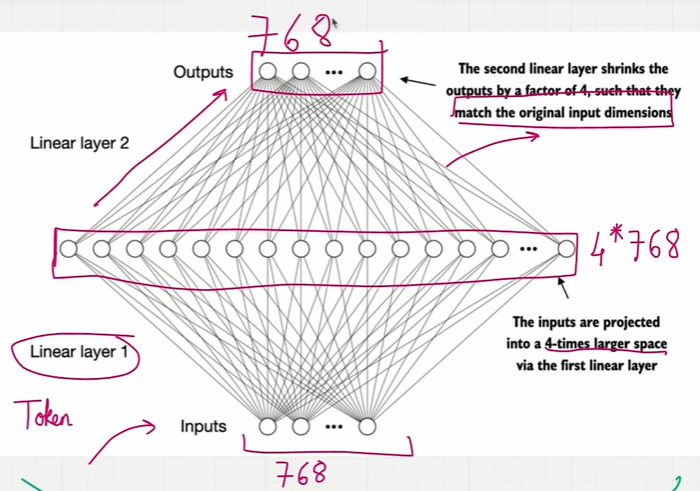

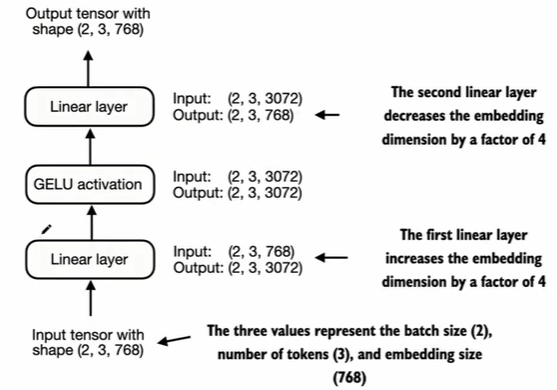


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Difference between Feed Forward neural network and Multi head attention :
    <ul>
        <li>Feed Forward neural network focuses on single token.</li>
        <li>Multi head attention also considers token's relation with other tokens.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Next, let's use the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later:
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>nn.Sequential PyTorch module for constructing and chaining neural network.</li>
        <li>We can define multiple layers and create a neural network by adding these different layers together sequentially.</li>
    </ul>
</div>

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]), #Expansion
            GELU(), #Activation
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]) #Contraction
        )
    
    def forward(self, x):
        return self.layers(x)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see in the preceding code, the FeedForward module is a small neural network consisting of two Linear layers and a GELU activation function.</li>
        <li>In the 124 million parameter GPT model, it receives the input batches with tokens that have an embedding size of 768 each via the GPT_CONFIG_124M dictionary where GPT_CONFIG_124M["emb_dim"] = 768.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
   Let's use the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later:
</div>

In [15]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The FeedForward module we implemented in this section plays a crucial role in enhancing the model's ability to learn from and generalize the data.</li>
        <li>Although the input and output dimensions of this module are the same, it internally expands the embedding dimension into a higher-dimensional space through the first linear layer.</li>
        <li>This expansion is followed by a non-linear GELU activation, and then a contraction back to the original dimension with the second linear transformation.</li>
        <li>Such a design allows for the exploration of a richer representation space.</li>
        <li>Moreover, the uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers, as we will do later, without the need to adjust dimensions between them, thus making the model more scalable.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of GELU activation and feed forward block:</b>
    <ul>
        <li>We need the FFN (Feed Forward Network) because it provides nonlinearity, depth, and expressive power.</li>
        <li>We need activation in Transformers because it adds nonlinearity, which is essential for the model to learn complex patterns.</li>
        <li>Without it, the entire Transformer becomes a stack of linear operations and loses expressive power.</li>
        <li><b>GELU(x) ≈ 0.5x(1 + tanh(sqrt(2/pi)*(x + 0.044715*x^3)))</b></li>
        <li>In Feed Forward neural network, First layer increases the embedding dimension by a factor of 4. Then on that input GELU activation is applied. Then second linear layer decreases the embedding dimension by a factor of 4.</li>
    </ul>
</div>

<h1>GPT ARCHITECTURE PART 4: SHORTCUT CONNECTIONS</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Also known as skip or residual connections.</li>
        <li>Shortcut connections were first proposed in the field of computer vision to solve the problem of vanishing gradient.</li>
        <li>Vanishing gradient problem : Gradients become progressively smaller as they propogate backwards in neural neteork, making it difficult to train earlier layers. Which leads to LLMs not learning very well.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Here's a deep neural network with 3 hidden layers
</div>

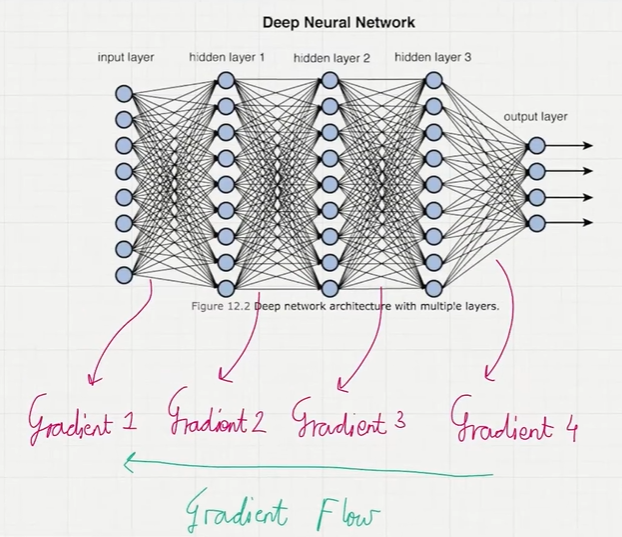

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>When we do backward pass, we find the gradients with respect to all the weights in that particular layer.</li>
        <li>Here Gradient 4 is a matrix of all gradients in the output layer.</li>
        <li>Gradient 3 is a matrix of all gradients in the hidden layer 3.</li>
        <li>Gradient 2 is a matrix of all gradients in the hidden layer 2.</li>
        <li>Gradient 1 is a matrix of all gradients in the hidden layer 1.</li>
        <li>Gradient flow direction always from output of neural network to the input of neural network.</li>
        <li>Now if Gradient 4 becomes small, and we multiply it with back propogated value, it get smaller. And gradients of each layers keep getting smaller till we reach Gradien 1.</li>
    </ul>
</div>

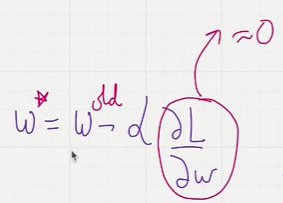

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In above image, is the formula to calculate new weights from old weights.</li>
        <li>When gradient keeps getting smaller and gradient which is derivative loss with respect to weight approaches 0, weigth will not get updated at all. Which means that neural network is not learning at all. Which is called <b>Vanishing gradient problem</b>.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Shortcut connections create an alternative path for tha gradient to flow, by skipping one or more layers.</li>
        <li>This is achieved by adding the output of one layer to the output of a latter layer.</li>
        <li>They are also called skip connections.</li>
        <li>Plays a crucial role in presenting flow of gradient during training backward pass.</li>
    </ul>
    Below is the pictorial illustration of shortcut connection :
</div>


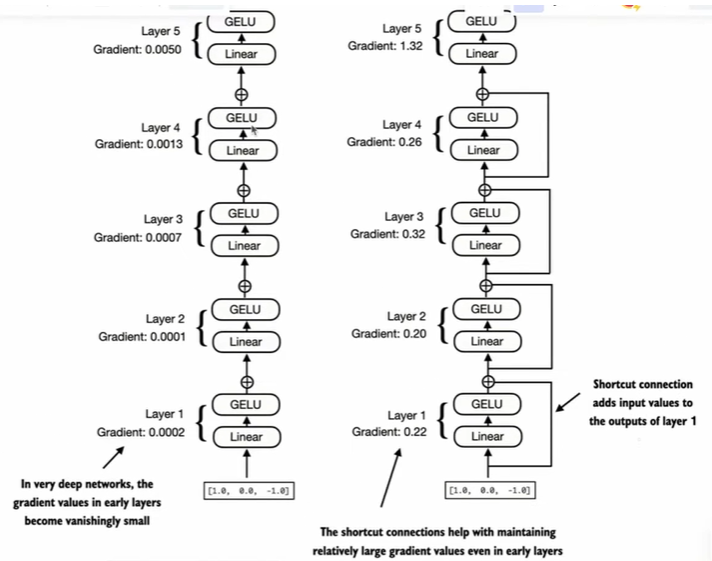
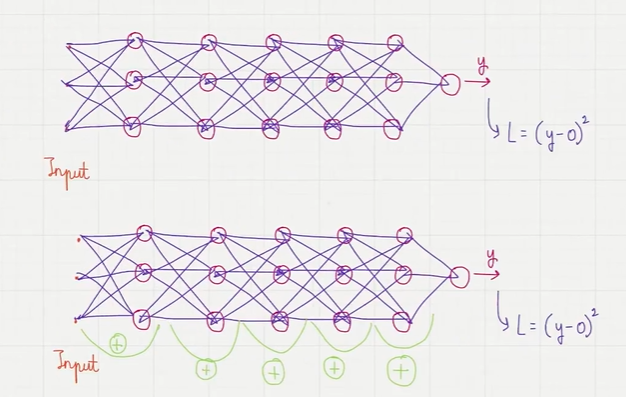

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Mathematical understanding:
</div>

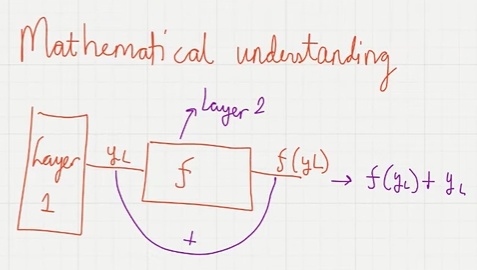

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    In above image yL is output of first layer and f(yL)+ yL is the ouput of second layer as we've added output of previous layer to the output of current layer.
</div>

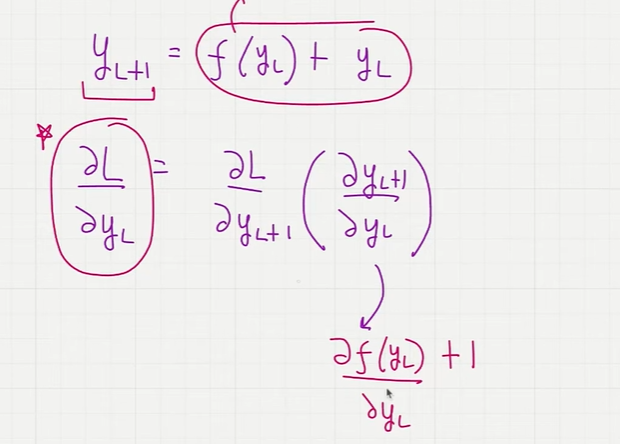
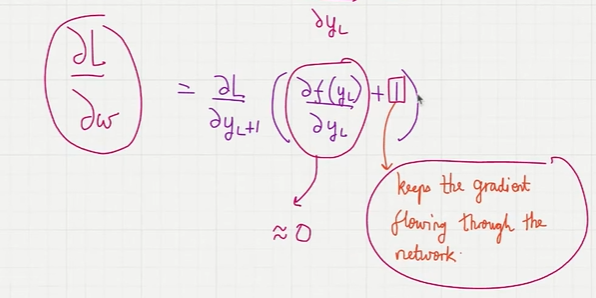

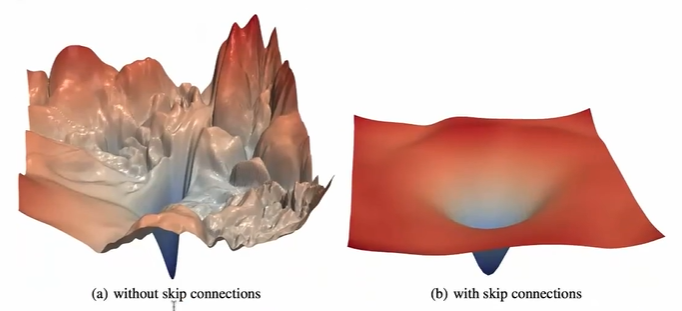

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let us see how we can add shortcut connections to the forward method:
</div>

In [16]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        
        return x

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The code implements a deep neural network with 5 layers, each consisting of a Linear layer and a GELU activation function.</li>
        <li>In the forward pass, we iteratively pass the input through the layers and optionally add the shortcut connections if the self.use_shortcut attribute is set to True.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let's use this code to first initialize a neural network without shortcut connections. Here, each layer will be initialized such that it accepts an example with 3 input values and returns 3 output values. The last layer returns a single output value:
</div>

In [17]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, we implement a function that computes the gradients in the the model's backward pass:
</div>

In [18]:
def print_gradients(model, x):
    #Foorward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In the preceding code, we specify a loss function that computes how close the model output and a user-specified target (here, for simplicity, the value 0) are.</li>
        <li>Then, when calling loss.backward(), PyTorch computes the loss gradient for each layer in the model.</li>
        <li>We can iterate through the weight parameters via model.named_parameters().</li>
        <li>Suppose we have a 3×3 weight parameter matrix for a given layer.</li>
        <li>In that case, this layer will have 3×3 gradient values, and we print the mean absolute gradient of these 3×3 gradient values to obtain a single gradient value per layer to compare the gradients between layers more easily.</li>
        <li>In short, the .backward() method is a convenient method in PyTorch that computes loss gradients, which are required during model training, without implementing the math for the gradient calculation ourselves, thereby making working with deep neural networks much more accessible.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's now use the print_gradients function and apply it to the model without skip connections:
</div>

In [19]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    As we can see based on the output of the print_gradients function, the gradients become smaller as we progress from the last layer (layers.4) to the first layer (layers.0), which is a phenomenon called the vanishing gradient problem.
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's now instantiate a model with skip connections and see how it compares:
</div>

In [20]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.2216978669166565
layers.1.0.weight has gradient mean of 0.20694100856781006
layers.2.0.weight has gradient mean of 0.3289698660373688
layers.3.0.weight has gradient mean of 0.2665731906890869
layers.4.0.weight has gradient mean of 1.3258538246154785


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, based on the output, the last layer (layers.4) still has a larger gradient than the other layers.</li>
        <li>However, the gradient value stabilizes as we progress towards the first layer (layers.0) and doesn't shrink to a vanishingly small value.</li>
        <li>Shortcut connections are a core building block of very large models such as LLMs, and they will help facilitate more effective training by ensuring consistent gradient flow across layers when we train the GPT model</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Shortcut connection:</b>
    <ul>
        <li>When gradient keeps getting smaller and gradient which is derivative loss with respect to weight approaches 0, weigth will not get updated at all. Which means that neural network is not learning at all. Which is called <b>Vanishing gradient problem</b>.</li>
        <li>shortcut connections are important for overcoming the limitations posed by the vanishing gradient problem in deep neural networks.</li>
        <li>To make shortcut connection we add output of last layer to the output of current layer.</li>
        <li><b>The skip connections (shortcut connections) we created are alternate way in backward propogation for gradients to flow from output to first layer.</b></li>
        <li>Due to shortcut connection gradient will not fall too low which will solve vanishing gradient problem and it stabilizes the training.</li>
    </ul>
</div>

<h1>GPT ARCHITECTURE PART 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The transformer block is repeated 12 times in GPT-2 small (124 M Parameter)</li>
        <li>When a transformer block processes an input seuence, each element is represented by a fixed size vector.</li>
        <li>The operations within the transformer block such as multi-head attention and feed forward layers, are designed to transform the input vectors such that their dimensionality is preserved.</li>
        <li><b>Attention</b> -> Analyzes relationship between input elemnts <b>VS</b> <b>Feed forward network</b> -> Modifies data individually at each position.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let us code a transformer block as follows:
</div>

In [21]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.w_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.w_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.w_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.w_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.w_query(x)
        values = self.w_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [22]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        #Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x) #Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # Add the original input back

        return x

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The given code defines a TransformerBlock class in PyTorch that includes a multi-head attention mechanism (MultiHeadAttention) and a feed forward network (FeedForward), both configured based on a provided configuration dictionary (cfg), such as GPT_CONFIG_124M</li>
        <li>Layer normalization (LayerNorm) is applied before each of these two components, and dropout is applied after them to regularize the model and prevent overfitting. This is also known as Pre-LayerNorm.</li>
        <li>Older architectures, such as the original transformer model, applied layer normalization after the self-attention and feed-forward networks instead, known as Post-LayerNorm, which often leads to worse training dynamics.</li>
        <li>The class also implements the forward pass, where each component is followed by a shortcut connection that adds the input of the block to its output. This critical feature helps gradients flow through the network during training and improves the learning of deep models</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Using the GPT_CONFIG_124M dictionary we defined earlier, let's instantiate a transformer block and feed it some sample data.</li>
        <li>Create sample input of shape [batch_size, num_tokens, emb_dim]</li>
    </ul>
</div>

In [23]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) #A
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see from the code output, the transformer block maintains the input dimensions in its output, indicating that the transformer architecture processes sequences of data without altering their shape throughout the network.</li>
        <li>The preservation of shape throughout the transformer block architecture is not incidental but a crucial aspect of its design.</li>
        <li>This design enables its effective application across a wide range of sequence-to-sequence tasks, where each output vector directly corresponds to an input vector, maintaining a one-to-one relationship.</li>
        <li>However, the output is a context vector that encapsulates information from the entire input sequence.</li>
        <li>This means that while the physical dimensions of the sequence (length and feature size) remain unchanged as it passes through the transformer block, the content of each output vector is re-encoded to integrate contextual information from across the entire input sequence.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Transformer block:</b>
    <ul>
        <li>Created a <b>TransformerBlock</b> class and implemented logic of a transformer block which we've seen earlier.</li>
        <li>TransformerBlock is encapsulation of every elements of transformers block we've learned earlier.</li>
    </ul>
</div>

<h1>GPT ARCHITECTURE PART 6: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION</h1>

Summarizing whole architecture by example :
https://www.youtube.com/watch?v=G3-JgHckzjw&list=PLPTV0NXA_ZSgsLAr8YCgCwhPIJNNtexWu&index=24

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>After data passes through all transformer blocks, another layer normalization is applied to output.</li>
        <li>After this layer normalization, we pass it to neural network. As an output of this layer, we get 50257 dimensional matrix for each token (50257 because vocabulary size is 50257). So if we pass 4 tokens as an input then output of this layer will be 4*50257 matrix. 4*50257 dimensional matrix is called logits.</li>
        <li>Each 50257 dimensional matrix for each token contains probability of it being the next token. In next token generation we look at this 50257 dimensional logits matrix.</li>
        <li>If we jave multiple batches of input tokens then output of this neural network is : <b>(no. of batches)*(no. of tokens)*(vocabulary size)</b></li>
    </ul>
</div>

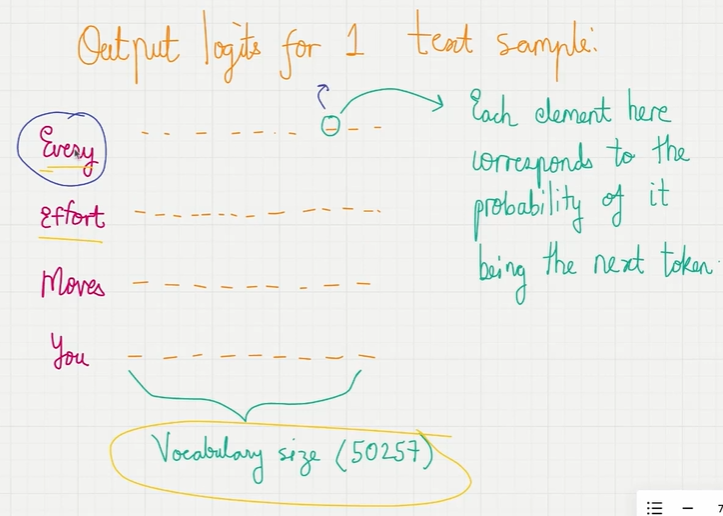

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    The device setting will allow us to train the model on a CPU or GPU, depending on which device the input data sits
</div>

In [24]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The init constructor of this GPTModel class initializes the token and positional embedding layers using the configurations passed in via a Python dictionary, cfg.</li>
        <li>These embedding layers are responsible for converting input token indices into dense vectors and adding positional information.</li>
        <li>Next, the init method creates a sequential stack of TransformerBlock modules equal to the number of layers specified in cfg.</li>
        <li>Following the transformer blocks, a LayerNorm layer is applied, standardizing the outputs from the transformer blocks to stabilize the learning process.</li>
        <li>Finally, a linear output head without bias is defined, which projects the transformer's output into the vocabulary space of the tokenizer to generate logits for each token in the vocabulary.</li>
        <li>The forward method takes a batch of input token indices, computes their embeddings, applies the positional embeddings, passes the sequence through the transformer blocks, normalizes the final output, and then computes the logits, representing the next token's unnormalized probabilities. We will convert these logits into tokens and text outputs in the next section.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M dictionary we pass into the cfg parameter and feed it with the batch text input we created at the beginning of this chapter:
</div>

In [25]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of the tokenizer. In the next section, we will see how to convert each of these 50,257- dimensional output vectors back into tokens.</li>
        <li>Using the numel() method, short for "number of elements," we can collect the total number of parameters in the model's parameter tensors:</li>
    </ul>
</div>

In [26]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li><b>Parameter in LLM : A parameter in an LLM is a trainable weight used in computations inside the network.</b></li>
        <li>A parameter = a knob the model can tune. More knobs → more ability to learn → but also more memory and cost.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Earlier, we spoke of initializing a 124 million parameter GPT model, so why is the actual number of parameters 163 million, as shown in the preceding code output?
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The reason is a concept called weight tying that is used in the original GPT-2 architecture, which means that the original GPT-2 architecture is reusing the weights from the token embedding layer in its output layer.</li>
        <li>To understand what this means, let's take a look at the shapes of the token embedding layer and linear output layer that we initialized on the model via the GPTModel earlier:</li>
    </ul>
</div>

In [27]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see based on the print outputs, the weight tensors for both these layers have the same shape:</li>
        <li>The token embedding and output layers are very large due to the number of rows for the 50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from the total GPT-2 model count according to the weight tying:</li>
    </ul>
</div>

In [28]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, the model is now only 124 million parameters large, matching the original size of the GPT-2 model.</li>
        <li>Weight tying reduces the overall memory footprint and computational complexity of the model. However, in my experience, using separate token embedding and output layers results in better training and model performance; hence, we are using separate layers in our GPTModel implementation. The same is true for modern LLMs.</li>
    </ul>
</div>

In [30]:
#Lastly, let us compute the memory requirements of the 163 million parameters in our GPTModel object:
total_size_bytes = total_params * 4 #A
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In conclusion, by calculating the memory requirements for the 163 million parameters in our GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we find that the total size of the model amounts to 621.83 MB, illustrating the relatively large storage capacity required to accommodate even relatively small LLMs.</li>
        <li>In this section, we implemented the GPTModel architecture and saw that it outputs numeric tensors of shape [batch_size, num_tokens, vocab_size]. In the next section, we will write the code to convert these output tensors into text.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of GPT model architecture:</b>
    <ul>
        <li>After all transformer blocks, we pass resultant embeddings in final Layer normalization.</li>
        <li>That normalized embeddings are passed into final output layer neural network. Input vector dimension for each token is 768 but output vector dimension for each token is 50257 (which is vocabulary size).</li>
        <li>Dimensions of output of this output head neural network is <b>(no. of batches)*(no. of tokens)*(vocabulary size)</b></li>
        <li>In this section we've implemented whole GPT architecture class.</li>
    </ul>
</div>

<h1>GPT ARCHITECTURE PART 7: GENERATING TEXT FROM OUTPUT TOKENS</h1>

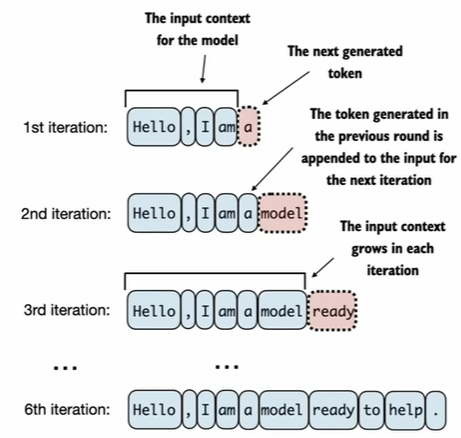

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>By using given input, GPT predicts one word in an iteration. Last iteration of word prediction gives us the desored word.</li>
        <li>GPT model gives logits as output. For each input token ID we get 50257 dimensional tensor which is same as vocabulary size. </li>
        <li>Index of this tensor represents a token in vocabulary and value of this index represents probability of that token for being next wword.</li>
        <li>We extract the last logits vector (50257 dimensional vector for last tokenId).</li>
        <li>Values of all logits don't add upto 1, which means values does not represent probabilities. So we apply softmax on this extracted vector. Now the values represents probabilities (Values adds upto 1).</li>
        <li>From this resultant vector, we find index with highest probability, we treat this index as tokenId and then we find what word for this tokenId from vocabulary.</li>
        <li>Highets probability for any index means that the tokenId possesses highest probability to become next generated word.</li>
        <li>Append tokenId to the previous inputs for the next round.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Here's the illustartion of how next word is predicted from output logits we get from GPTModel class.
</div>

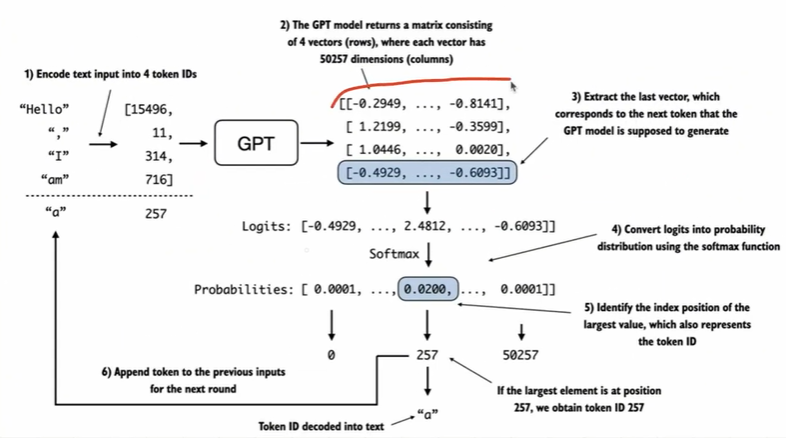

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    The figure below illustrates the process of generating one tokenID at a time
</div>

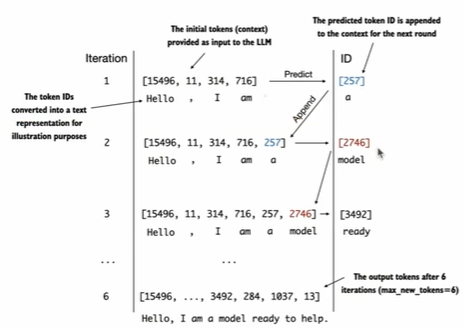

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    This step by step process enables the model to generate text sequentially, building coherent phrases from the initial input context
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let us implement the token-generation process as follows:
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Step 1: idx is a (batch, n_tokens) array of indices in the current context</li>
        <li>Step 2: Crop current context if it exceeds the supported context size E.g., if LLM supports only 5 tokens, and the context size is 10 then only the last 5 tokens are used as context</li>
        <li>Step 3: Focus only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)</li>
        <li>Step 4: probas has shape (batch, vocab_size)</li>
        <li>Step 5: idx_next has shape (batch, 1)</li>
        <li>Step 6: Append sampled index to the running sequence, where idx has shape (batch, n_tokens+1)</li>
    </ul>
</div>

In [37]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In the preceeding code, the generate_text_simple function, we use a softmax function to convert the logits into a probability distribution from which we identify the position with the highest value via torch.argmax.</li>
        <li>The softmax function is monotonic, meaning it preserves the order of its inputs when transformed into outputs.</li>
        <li>So, in practice, the softmax step is redundant since the position with the highest score in the softmax output tensor is the same position in the logit tensor.</li>
        <li>In other words, we could apply the torch.argmax function to the logits tensor directly and get identical results.</li>
        <li>However, we coded the conversion to illustrate the full process of transforming logits to probabilities, which can add additional intuition, such as that the model generates the most likely next token, which is known as greedy decoding.</li>
        <li>In the next chapter, when we will implement the GPT training code, we will also introduce additional sampling techniques where we modify the softmax outputs such that the model doesn't always select the most likely token, which introduces variability and creativity in the generated text.</li>
        <li>Let's now try out the generate_text_simple function with the "Hello, I am" context as model input</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    First, we encode the input context into token IDs:
</div>

In [38]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) 
print("encoded_tensor.shape:", encoded_tensor) #encoded_tensor is input tensor with only 1 batch

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: tensor([[15496,    11,   314,   716]])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Next, we put the model into .eval() mode, which disables random components like dropout, which are only used during training, and use the generate_text_simple function on the encoded input tensor:</li>
        <li>We disable dropout since we are not training the model</li>
    </ul>
</div>

In [39]:
model.eval() #A
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Using the .decode method of the tokenizer, we can convert the IDs back into text:
</div>

In [40]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, based on the preceding output, the model generated gibberish, which is not at all coherent text.</li>
        <li>What happened?</li>
        <li>The reason why the model is unable to produce coherent text is that we haven't trained it yet.</li>
        <li>So far, we just implemented the GPT architecture and initialized a GPT model instance with initial random weights.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Generating text from output tokens:</b>
    <ul>
        <li>Step 1 : From GPT output, we get a tensor with dimensions (no. of batches* no. of tokens* vocab_size). Extract logits for last token for every batch. Dimensions of extracted tensor is (no. of batches * vocab_size).</li>
        <li>Step 2 : Apply softmax on logits to get probabilities for each tokens.</li>
        <li>Step 3 : Extract index which contains largest probability. We treat index which contains largest probability in this tensor as tokenID which posseses highest possibility to become next word.</li>
        <li>Step 4 : Append that next tokenID to input tokenIDs. And decode the tokenIDs to get sentence from vocabulary.</li>
        <li>In this section weve implemented generate_text_simple() method which encompasses logic to predict next word for given input tokenIDs.</li>
    </ul>
</div>